# MultiHead Sweep Results
Loads all `checkpoints/multihead/*/best.pt` and visualises performance across sweep axes.

Primary metric: **mean cosine similarity** (SigLIP + CLIP heads). Secondary: 2-AFC, per-head breakdown.

In [30]:
import sys
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from tqdm.notebook import tqdm

sys.path.insert(0, '.')
from config_const import CHECKPOINT_DIR

SWEEP_AXES = ['loss_weight_t5', 'd_model', 'n_layers', 'shared_dim', 't5_pca_k']

def load_one(pt):
    try:
        ckpt = torch.load(pt, weights_only=False, map_location='cpu')
    except Exception:
        return None
    row = {**ckpt['args'], **ckpt['metrics'], 'path': str(pt)}
    if 'test_metrics' in ckpt:
        row.update(ckpt['test_metrics'])
    return row

candidates = sorted((CHECKPOINT_DIR / 'multihead').glob('*/best.pt'))
records = []
with ThreadPoolExecutor(max_workers=8) as pool:
    futures = {pool.submit(load_one, pt): pt for pt in candidates}
    for fut in tqdm(as_completed(futures), total=len(futures), desc='Loading'):
        row = fut.result()
        if row:
            records.append(row)

df = pd.DataFrame(records)
has_test = 'test_cos_siglip' in df.columns

for col in SWEEP_AXES:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col])

# val_mean_2afc is now (sig_2afc + clip_2afc + t5_cos) / 3 for new runs
SORT_BY = 'val_mean_2afc'
show_cols = SWEEP_AXES + ['val_mean_2afc', 'val_cos_siglip', 'val_cos_clip', 'val_cos_t5']
show_cols = [c for c in show_cols if c in df.columns]

print(f'{len(df)} runs loaded  |  test metrics present: {has_test}')
print(df[show_cols].sort_values(SORT_BY, ascending=False).to_string(index=False))

Loading:   0%|          | 0/32 [00:00<?, ?it/s]

32 runs loaded  |  test metrics present: True
 loss_weight_t5  d_model  n_layers  shared_dim  t5_pca_k  val_mean_2afc  val_cos_siglip  val_cos_clip  val_cos_t5
            0.5      128         2         256       256       0.532486        0.726270      0.397024    0.090110
            0.5       64         2         256       128       0.532008        0.723977      0.399020    0.102146
            0.5      128         2         256       128       0.531549        0.739004      0.414004    0.114648
            0.5       64         4         256       128       0.528084        0.719295      0.389420    0.109966
            0.5       64         2         256       256       0.527690        0.716280      0.394279    0.105112
            1.0      128         4         256       128       0.525415        0.716518      0.393896    0.094614
            1.0      128         2         256       256       0.525006        0.733353      0.400919    0.078283
            1.0      128         2        

## Best run per loss_weight_t5

In [31]:
cols = ['loss_weight_t5', 'd_model', 'n_layers', 'shared_dim', 't5_pca_k', 'nce_weight',
        'val_mean_2afc', 'val_2afc_siglip', 'val_2afc_clip',
        'val_cos_siglip', 'val_cos_clip', 'val_cos_t5']
available = [c for c in cols if c in df.columns]
summary = (
    df.sort_values('val_mean_2afc', ascending=False)
      .groupby('loss_weight_t5', sort=True)
      .first()
      .reset_index()
)[available]
display(summary)

,loss_weight_t5,d_model,n_layers,shared_dim,t5_pca_k,nce_weight,val_mean_2afc,val_2afc_siglip,val_2afc_clip,val_cos_siglip,val_cos_clip,val_cos_t5
0,0.5,128,2,256,256,0.05,0.532486,0.802449,0.704898,0.726270,0.397024,0.090110
1,1.0,128,4,256,128,0.05,0.525415,0.791837,0.689796,0.716518,0.393896,0.094614


## Cosine similarity and 2-AFC by sweep axis

/tmp/ipykernel_18250/2910986280.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  wt5_cmap  = plt.cm.get_cmap('Set1', len(wt5_vals))


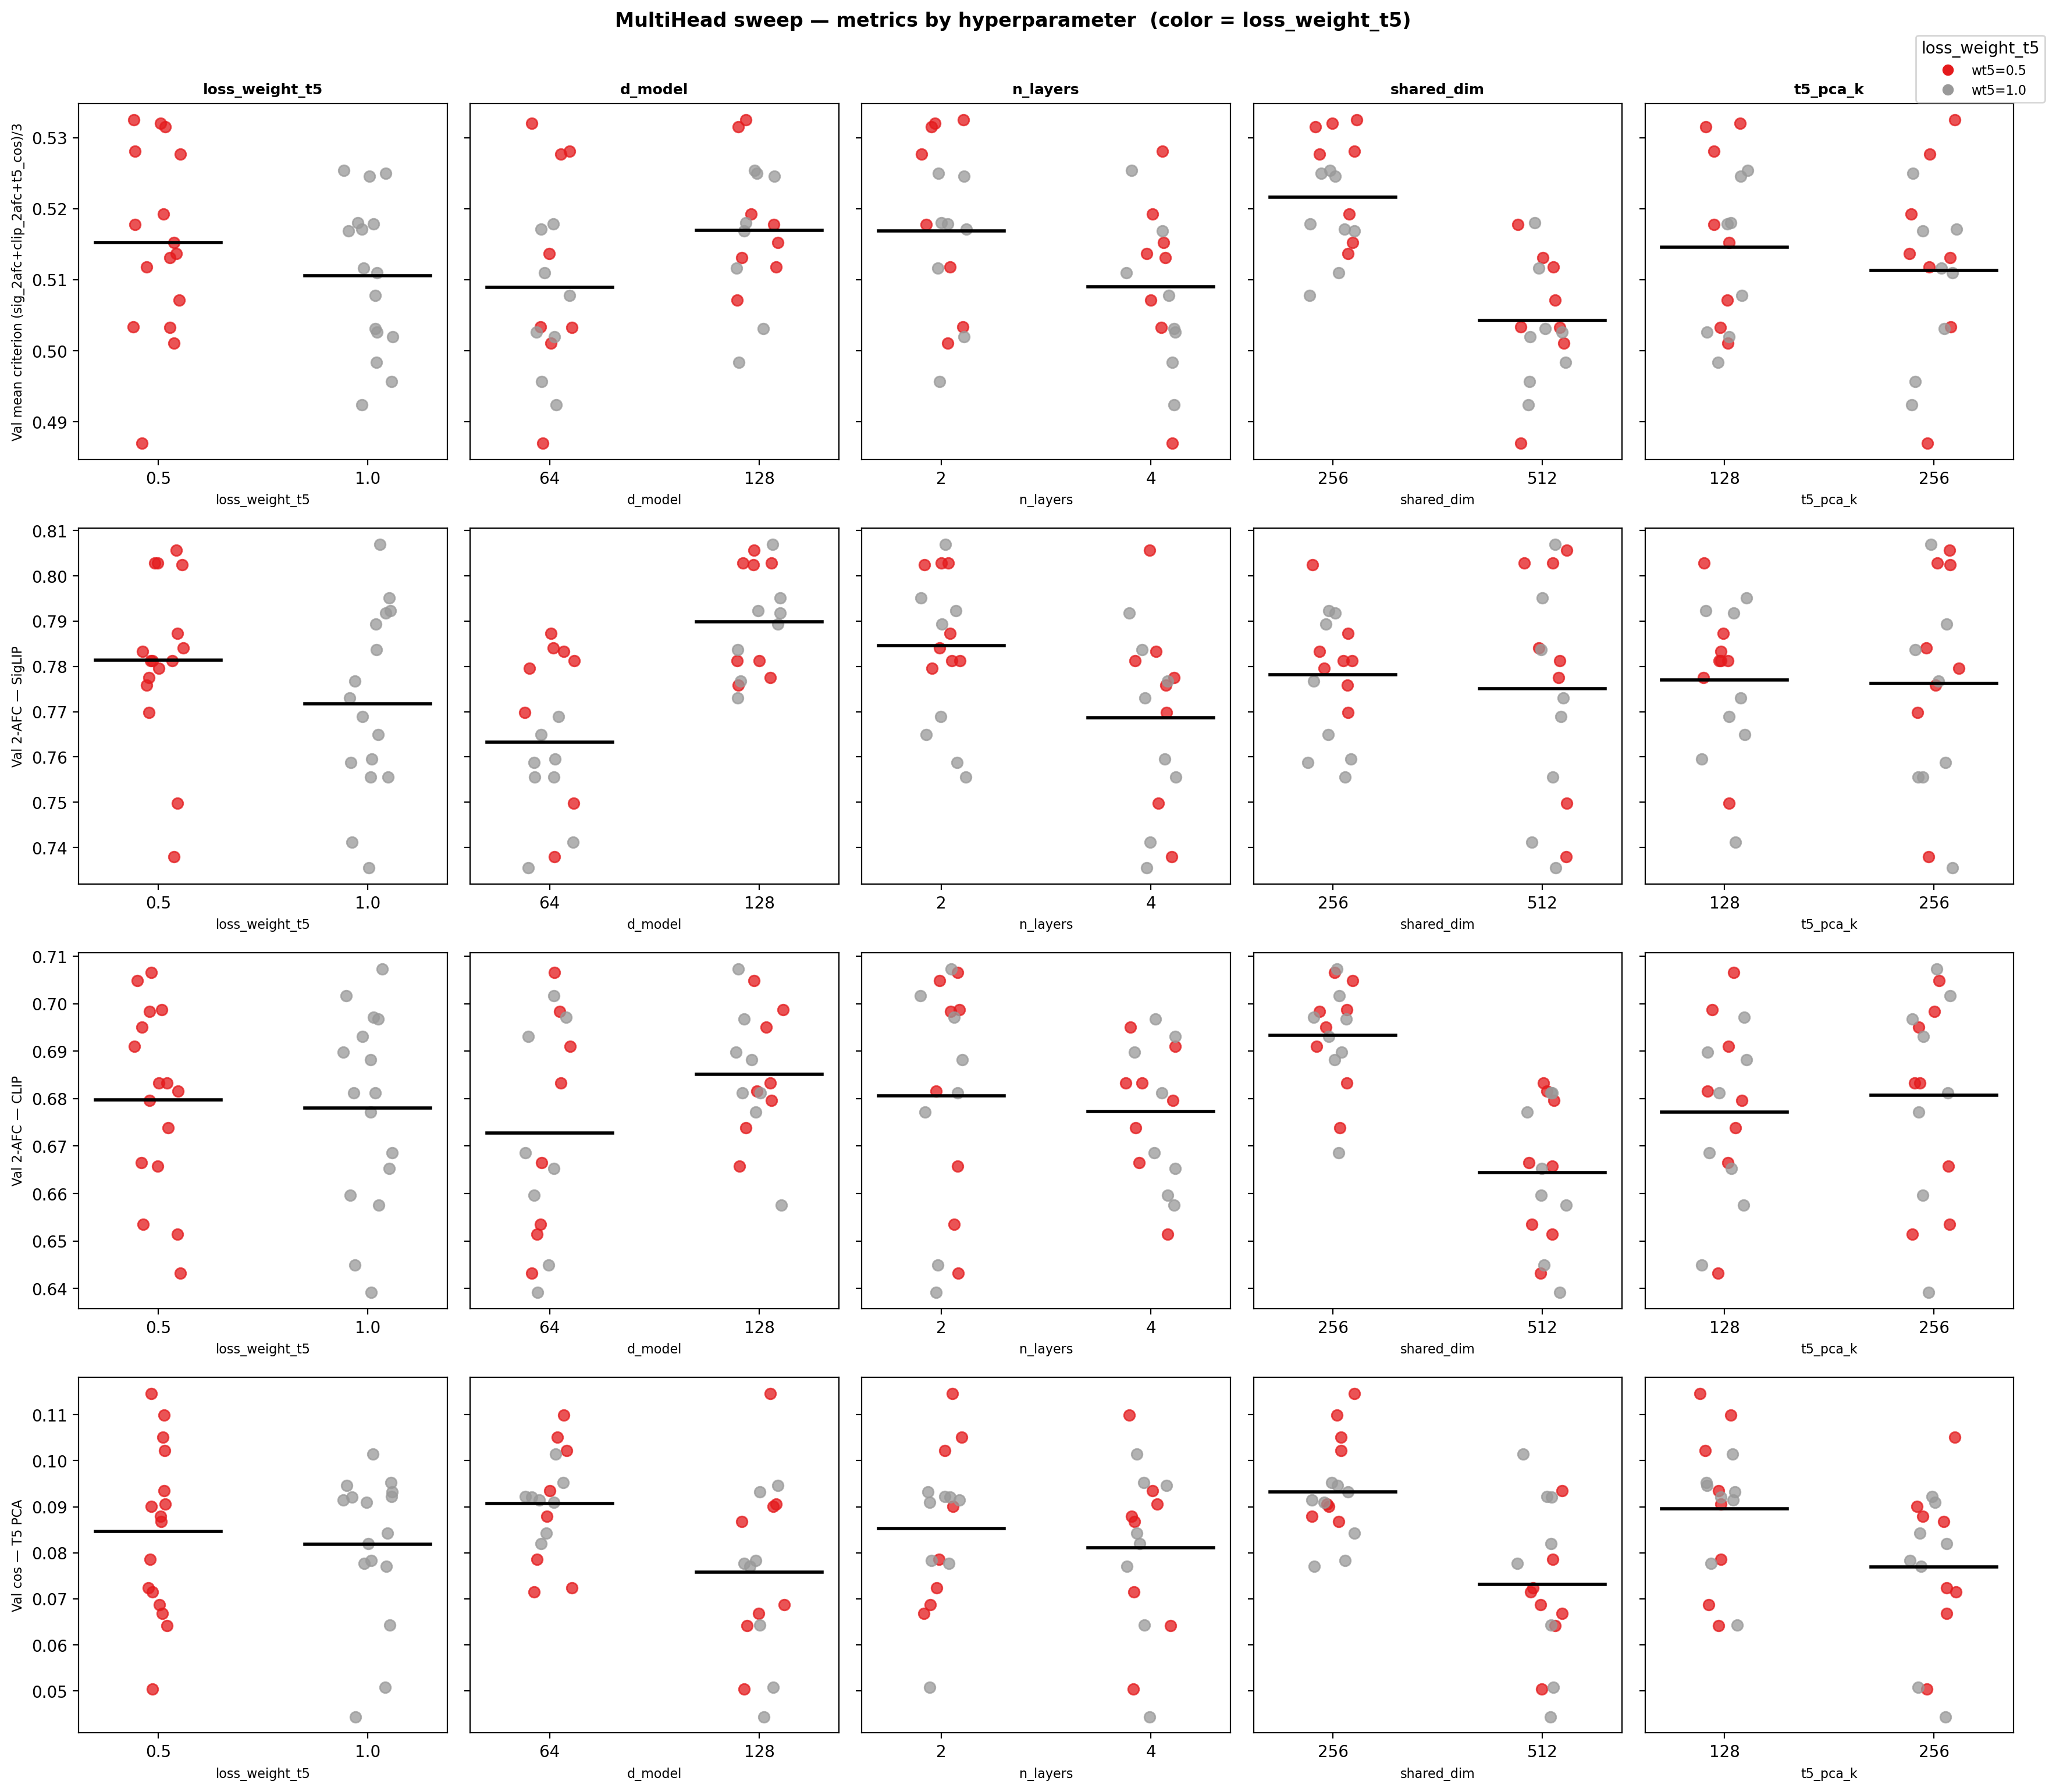

In [32]:
METRICS = [
    ('val_mean_2afc',  'Val mean criterion (sig_2afc+clip_2afc+t5_cos)/3'),
    ('val_2afc_siglip','Val 2-AFC — SigLIP'),
    ('val_2afc_clip',  'Val 2-AFC — CLIP'),
    ('val_cos_t5',     'Val cos — T5 PCA'),
]

fig, axes = plt.subplots(len(METRICS), len(SWEEP_AXES),
                         figsize=(3.5 * len(SWEEP_AXES), 3.8 * len(METRICS)),
                         sharey='row', squeeze=False)

rng = np.random.default_rng(0)

wt5_vals  = sorted(df['loss_weight_t5'].unique())
wt5_cmap  = plt.cm.get_cmap('Set1', len(wt5_vals))
wt5_color = {v: wt5_cmap(i) for i, v in enumerate(wt5_vals)}

for mi, (metric, ylabel) in enumerate(METRICS):
    if metric not in df.columns:
        continue
    for ai, axis_col in enumerate(SWEEP_AXES):
        ax = axes[mi, ai]
        if axis_col not in df.columns:
            ax.axis('off'); continue
        levels = sorted(df[axis_col].unique())
        for lvl_i, lvl in enumerate(levels):
            sub = df[df[axis_col] == lvl]
            for wt5, grp in sub.groupby('loss_weight_t5'):
                vals = grp[metric].dropna().values
                if not len(vals): continue
                jitter = rng.uniform(-0.12, 0.12, len(vals))
                ax.scatter(np.full(len(vals), lvl_i) + jitter, vals,
                           color=wt5_color[wt5], alpha=0.75, s=45,
                           label=f'wt5={wt5}' if ai == 0 and lvl_i == 0 else '_')
            all_vals = sub[metric].dropna().values
            if len(all_vals):
                ax.plot([lvl_i - 0.3, lvl_i + 0.3],
                        [all_vals.mean(), all_vals.mean()], 'k-', lw=2)
        ax.set_xticks(range(len(levels)))
        ax.set_xticklabels([str(l) for l in levels])
        ax.set_xlabel(axis_col, fontsize=8)
        if ai == 0:
            ax.set_ylabel(ylabel, fontsize=8)
        if mi == 0:
            ax.set_title(axis_col, fontsize=9, fontweight='bold')

handles = [plt.Line2D([0],[0],marker='o',color='w',
           markerfacecolor=wt5_color[v],markersize=8,label=f'wt5={v}') for v in wt5_vals]
fig.legend(handles=handles, title='loss_weight_t5', loc='upper right',
           bbox_to_anchor=(1.01, 1), fontsize=8)
fig.suptitle('MultiHead sweep — metrics by hyperparameter  (color = loss_weight_t5)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Effect of loss_weight_t5 — key ablation

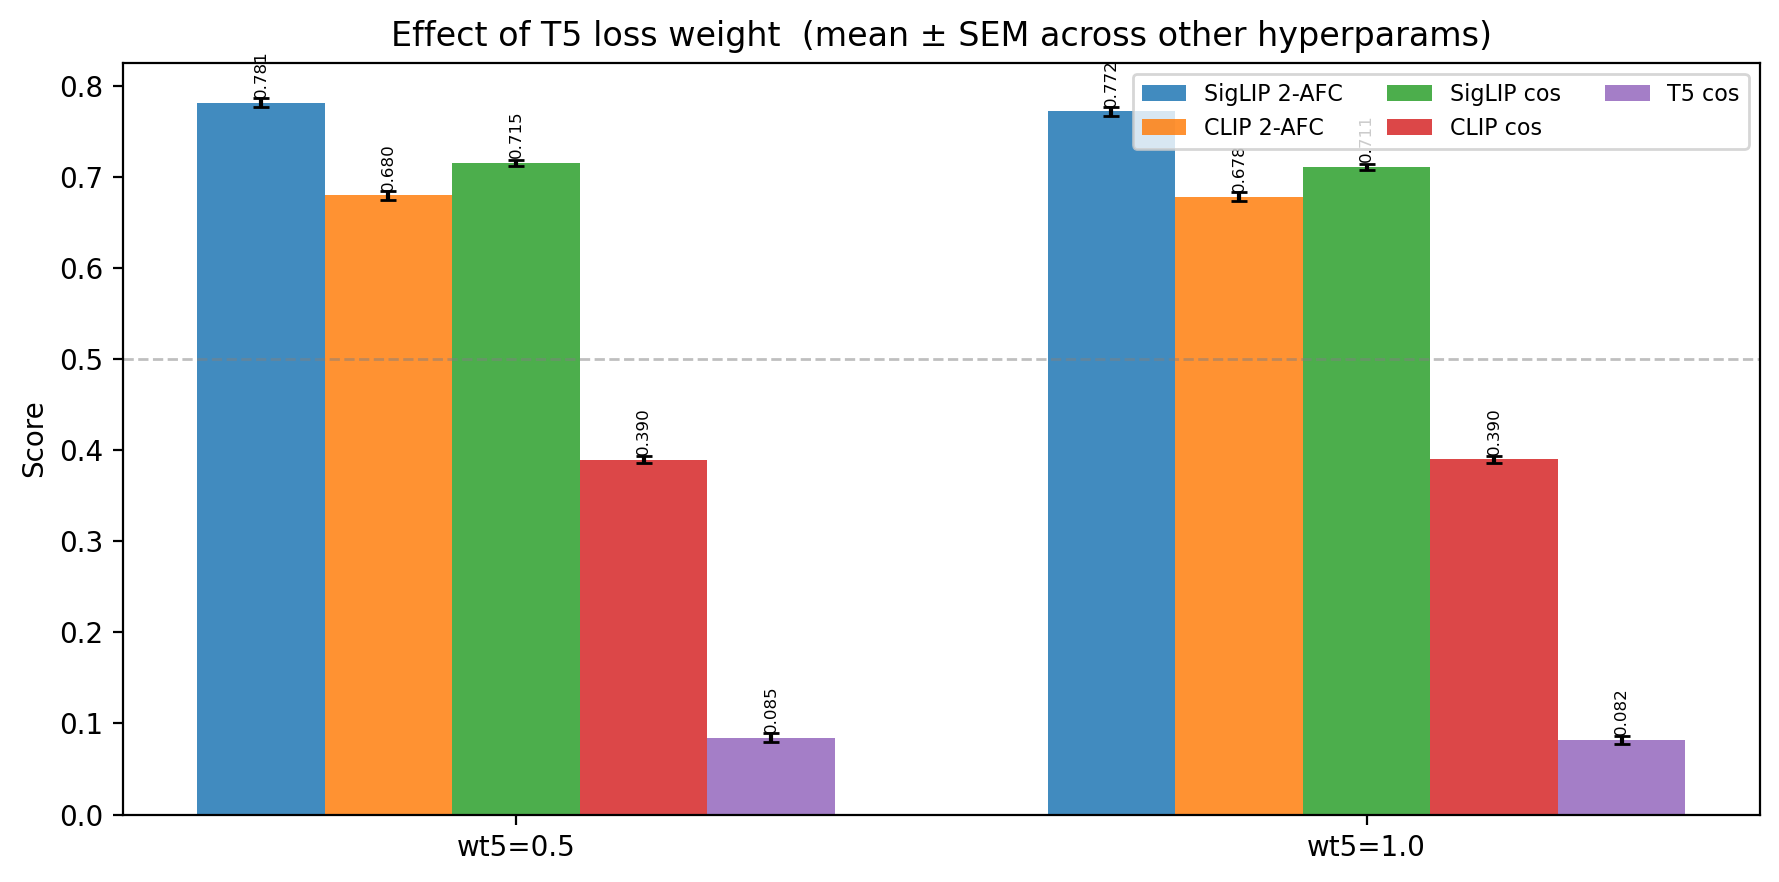

In [33]:
metrics_ab = [
    ('val_2afc_siglip', 'SigLIP 2-AFC'),
    ('val_2afc_clip',   'CLIP 2-AFC'),
    ('val_cos_siglip',  'SigLIP cos'),
    ('val_cos_clip',    'CLIP cos'),
    ('val_cos_t5',      'T5 cos'),
]
metrics_ab = [(m, l) for m, l in metrics_ab if m in df.columns]
wt5_labels = sorted(df['loss_weight_t5'].unique())
x = np.arange(len(wt5_labels))
width = 0.15

fig, ax = plt.subplots(figsize=(9, 4.5))
offsets = np.linspace(-(len(metrics_ab)-1)/2, (len(metrics_ab)-1)/2, len(metrics_ab)) * width

for off, (metric, label) in zip(offsets, metrics_ab):
    means = [df[df['loss_weight_t5'] == w][metric].mean() for w in wt5_labels]
    sems  = [df[df['loss_weight_t5'] == w][metric].sem()  for w in wt5_labels]
    bars  = ax.bar(x + off, means, width, yerr=sems, capsize=3, label=label, alpha=0.85)
    for bar, v in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=6, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels([f'wt5={v}' for v in wt5_labels])
ax.set_ylabel('Score')
ax.set_title('Effect of T5 loss weight  (mean ± SEM across other hyperparams)')
ax.legend(fontsize=8, ncol=3)
ax.axhline(0.5, color='grey', lw=1, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Val vs test generalisation

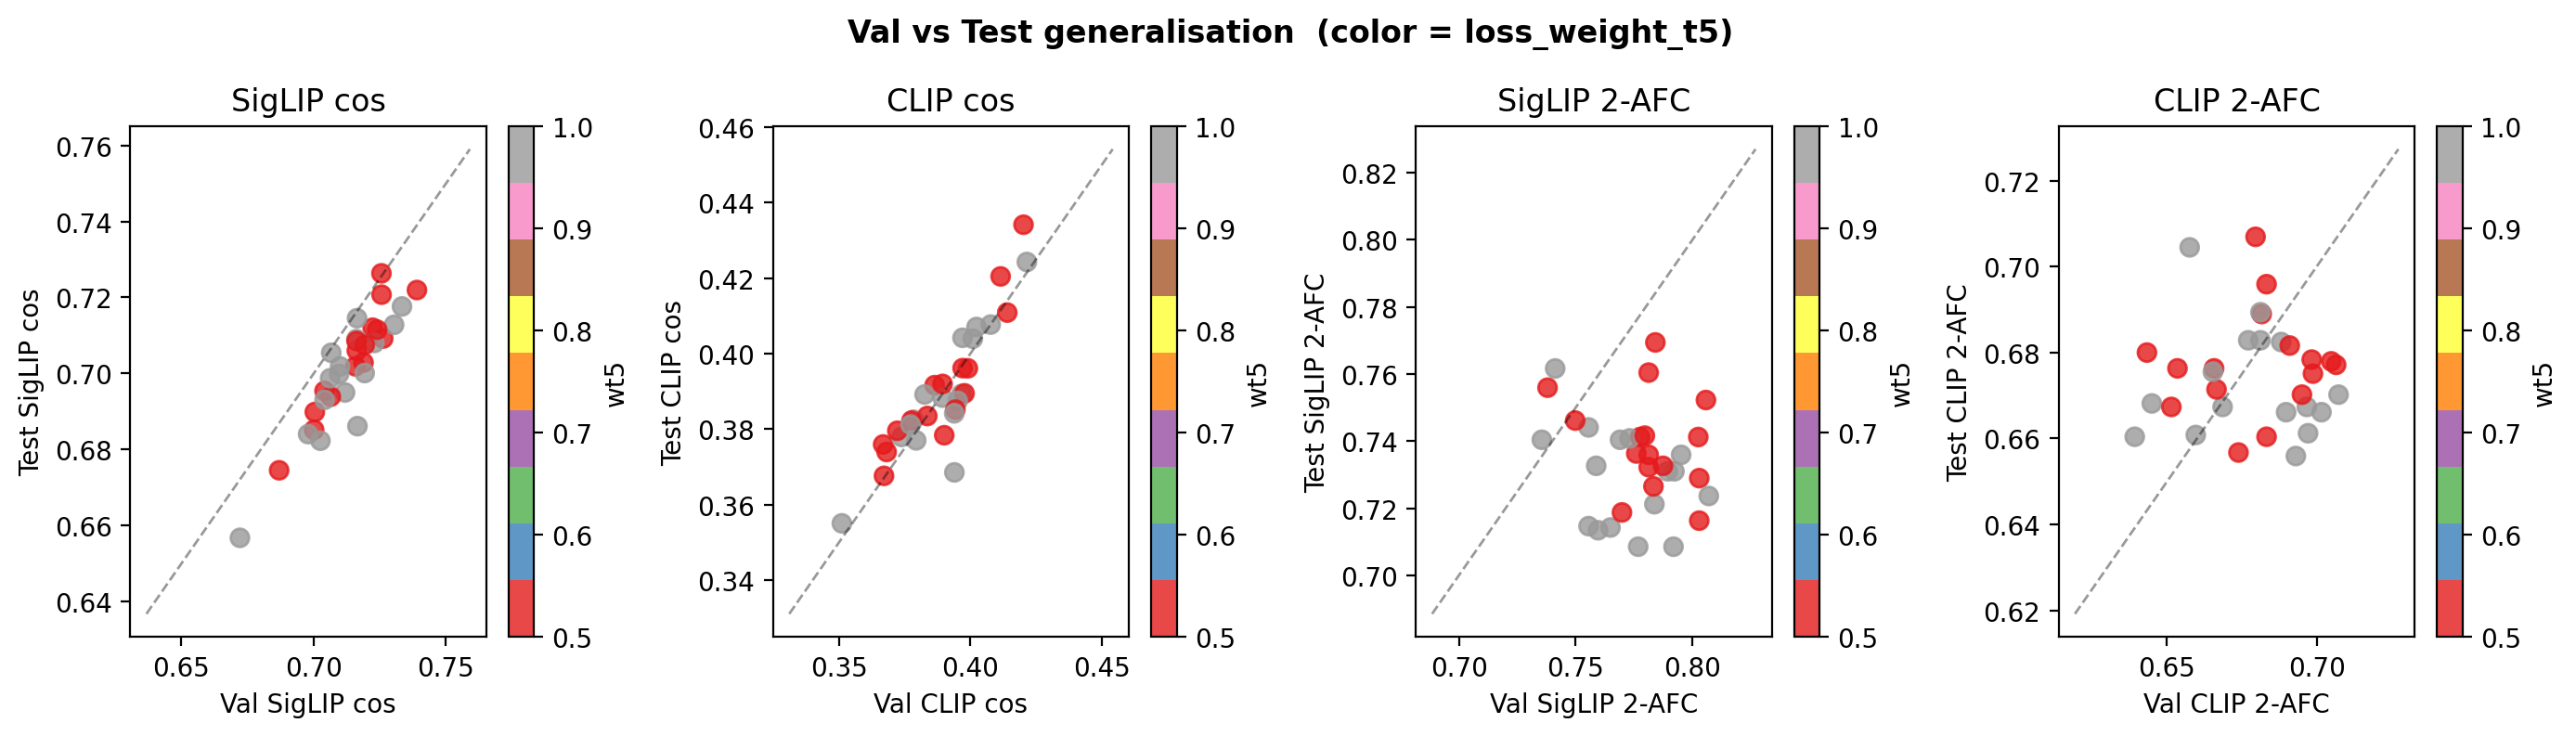

In [34]:
if has_test:
    pairs = [("val_cos_siglip","test_cos_siglip","SigLIP cos"),
             ("val_cos_clip",  "test_cos_clip",  "CLIP cos"),
             ("val_2afc_siglip","test_2afc_siglip","SigLIP 2-AFC"),
             ("val_2afc_clip",  "test_2afc_clip",  "CLIP 2-AFC")]
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    for ax, (vcol, tcol, title) in zip(axes, pairs):
        sub = df.dropna(subset=[vcol, tcol])
        sc = ax.scatter(sub[vcol], sub[tcol],
                        c=sub["loss_weight_t5"], cmap="Set1",
                        vmin=sub["loss_weight_t5"].min(),
                        vmax=sub["loss_weight_t5"].max(),
                        s=50, alpha=0.8)
        lim = [min(sub[vcol].min(), sub[tcol].min()) - 0.02,
               max(sub[vcol].max(), sub[tcol].max()) + 0.02]
        ax.plot(lim, lim, "k--", lw=1, alpha=0.4)
        ax.set_xlabel(f"Val {title}")
        ax.set_ylabel(f"Test {title}")
        ax.set_title(title)
        plt.colorbar(sc, ax=ax, label="wt5")
    fig.suptitle("Val vs Test generalisation  (color = loss_weight_t5)", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Test metrics not yet available — rerun once all jobs complete.")


## Top-10 runs by val mean cosine similarity

In [35]:
top_cols = [c for c in
    ['loss_weight_t5', 'd_model', 'n_layers', 'shared_dim', 't5_pca_k', 'nce_weight',
     'epoch', 'val_mean_2afc', 'val_2afc_siglip', 'val_2afc_clip', 'val_cos_t5',
     'val_cos_siglip', 'val_cos_clip',
     'test_cos_siglip', 'test_cos_clip',
     'test_2afc_siglip', 'test_2afc_clip', 'path']
    if c in df.columns]
display(df.sort_values('val_mean_2afc', ascending=False)[top_cols].head(10).reset_index(drop=True))

,loss_weight_t5,d_model,n_layers,shared_dim,t5_pca_k,nce_weight,epoch,val_mean_2afc,val_2afc_siglip,val_2afc_clip,val_cos_t5,val_cos_siglip,val_cos_clip,test_cos_siglip,test_cos_clip,test_2afc_siglip,test_2afc_clip,path
0,0.5,128,2,256,256,0.05,131,0.532486,0.802449,0.704898,0.090110,0.726270,0.397024,0.709197,0.396139,0.741224,0.677959,/home/yy3658/NeurObjectGen/checkpoints/multihe...
1,0.5,64,2,256,128,0.05,136,0.532008,0.787347,0.706531,0.102146,0.723977,0.399020,0.711515,0.396095,0.732653,0.677143,/home/yy3658/NeurObjectGen/checkpoints/multihe...
2,0.5,128,2,256,128,0.05,82,0.531549,0.781224,0.698776,0.114648,0.739004,0.414004,0.721948,0.410841,0.735918,0.675102,/home/yy3658/NeurObjectGen/checkpoints/multihe...
3,0.5,64,4,256,128,0.05,129,0.528084,0.783265,0.691020,0.109966,0.719295,0.389420,0.707524,0.391971,0.726531,0.681633,/home/yy3658/NeurObjectGen/checkpoints/multihe...
4,0.5,64,2,256,256,0.05,88,0.527690,0.779592,0.698367,0.105112,0.716280,0.394279,0.706001,0.385164,0.741633,0.678367,/home/yy3658/NeurObjectGen/checkpoints/multihe...
5,1.0,128,4,256,128,0.05,144,0.525415,0.791837,0.689796,0.094614,0.716518,0.393896,0.686148,0.368555,0.708571,0.666122,/home/yy3658/NeurObjectGen/checkpoints/multihe...
6,1.0,128,2,256,256,0.05,116,0.525006,0.789388,0.707347,0.078283,0.733353,0.400919,0.717627,0.403934,0.731020,0.670204,/home/yy3658/NeurObjectGen/checkpoints/multihe...
7,1.0,128,2,256,128,0.05,106,0.524546,0.792245,0.688163,0.093231,0.730365,0.407708,0.712803,0.407672,0.731020,0.682449,/home/yy3658/NeurObjectGen/checkpoints/multihe...
8,0.5,128,4,256,256,0.05,96,0.519261,0.775918,0.695102,0.086762,0.722284,0.397769,0.712041,0.389477,0.736327,0.670204,/home/yy3658/NeurObjectGen/checkpoints/multihe...
9,1.0,128,2,512,128,0.05,54,0.517988,0.795102,0.681224,0.077637,0.711823,0.389362,0.694999,0.388339,0.735918,0.689388,/home/yy3658/NeurObjectGen/checkpoints/multihe...


## Save best multihead config

In [36]:
import json
from config_const import CACHE_DIR

best_row = df[df['loss_weight_t5'] > 0].sort_values('val_mean_2afc', ascending=False).iloc[0]
config = {
    'model': 'multihead',
    'val_mean_2afc':  float(best_row['val_mean_2afc']),
    'val_cos_t5':     float(best_row['val_cos_t5']) if 'val_cos_t5' in best_row else None,
    'checkpoint': best_row['path'],
    'd_model':    int(best_row['d_model']),
    'n_heads':    int(best_row['n_heads']),
    'n_layers':   int(best_row['n_layers']),
    'shared_dim': int(best_row['shared_dim']),
    't5_pca_k':   int(best_row['t5_pca_k']),
    'dropout':    float(best_row['dropout']),
    'lr':         float(best_row['lr']),
    'weight_decay':       float(best_row['weight_decay']),
    'loss_weight_t5':     float(best_row['loss_weight_t5']),
    'loss_weight_siglip': float(best_row['loss_weight_siglip']),
    'loss_weight_clip':   float(best_row['loss_weight_clip']),
}

out_path = CACHE_DIR / 'best_multihead_config.json'
with open(out_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f'Saved to {out_path}')
print(f"  val_mean_2afc={config['val_mean_2afc']:.4f}")
if config['val_cos_t5']:
    print(f"  val_cos_t5={config['val_cos_t5']:.4f}")
print(f"  {config['checkpoint']}")

Saved to /home/yy3658/NeurObjectGen/cache/best_multihead_config.json
  val_mean_2afc=0.5325
  val_cos_t5=0.0901
  /home/yy3658/NeurObjectGen/checkpoints/multihead/d128_nh4_nl2_sd256_k256_do0.1_lr0.0003_wd0.01_tn0.02_bs64_ws1.0_wc1.0_wt0.5_uw0.1_nw0.05_nt0.07/best.pt
